In [1]:
# notwendige Libraries laden.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from PIL import Image
import io
import os
import glob
import base64
import cv2

In [2]:
# MNIST Auswahl-Datensatz als CSV einlesen: die einzelnen Spalten entsprechen Pixeln.

mnist = pd.read_csv('class_128_28x28.csv')
mnist.head(6)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Aufloesung in DPI: 100.0


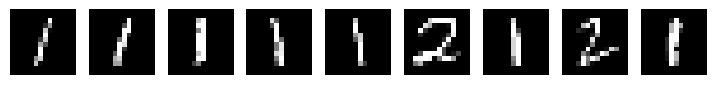

In [3]:
dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)
plt.figure(figsize = (10,1))

gesamtzahl = 10
for i in range(1,gesamtzahl):
    testbild = mnist.values[i,1:].reshape(28,28)
    testbild = testbild.astype('uint16')
    testlabel = mnist.values[i,0]
    
    img = Image.fromarray(testbild)
    img = img.resize((14,14))
    string = "mnist_"+str(testlabel)+"_"+str(i)+"_14x14.png"
    plt.imsave(string, img, cmap='gray')
    
    kleinesbild = np.asarray(img)
    kleinesbild = kleinesbild.astype('uint16')
    kleinesarray = kleinesbild.flatten()
    
    plt.subplot(1,gesamtzahl,i)
    plt.imshow(img)
       
    plt.axis('off')
    plt.gray()
    plt.imshow(kleinesbild, aspect=1, cmap='gray')
plt.show()

In [4]:
# Resizing der 28x28 Bilder auf 14x14. Dann werden die Bilder als 1D-Arrays in einer CSV-Datei abgespeichert.
gesamtzahl = mnist.shape[0]

spaltennamen = ['label']
bildarray = []

for i in range(0, 196):
    spaltennamen.append("p"+str(i))


for i in range(gesamtzahl):
    bild = mnist.values[i,1:].reshape(28,28)
    bild = bild.astype('uint16')
    label = mnist.values[i,0]
    
    img = Image.fromarray(bild)
    img = img.resize((14,14))
    
    kleinesbild = np.asarray(img)
    kleinesbild = kleinesbild.astype('uint16')
    kleinesarray = kleinesbild.flatten()
    neuesarray = np.insert(kleinesarray, 0, label)
    
    if i==0:
        df = pd.DataFrame([neuesarray], columns=spaltennamen)
    if i>0:
        #df = df.append(pd.DataFrame([neuesarray], columns=spaltennamen), ignore_index = True)
        df = pd.concat([df, pd.DataFrame([neuesarray], columns=spaltennamen)])

print(df['label'].value_counts())
df.to_csv('class_128_14x14.csv',index=False)

1    113
2    103
8     84
Name: label, dtype: int64


Aufloesung in DPI: 100.0
label: 1 höhe: 14 breite: 14


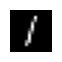

label: 1 höhe: 14 breite: 14


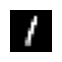

label: 1 höhe: 14 breite: 14


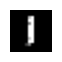

label: 1 höhe: 14 breite: 14


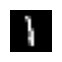

label: 1 höhe: 14 breite: 14


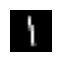

label: 2 höhe: 14 breite: 14


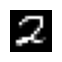

label: 1 höhe: 14 breite: 14


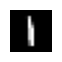

label: 2 höhe: 14 breite: 14


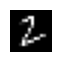

label: 1 höhe: 14 breite: 14


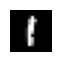

label: 1 höhe: 14 breite: 14


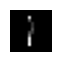

label: 2 höhe: 14 breite: 14


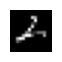

label: 1 höhe: 14 breite: 14


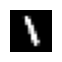

label: 2 höhe: 14 breite: 14


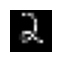

label: 1 höhe: 14 breite: 14


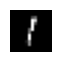

label: 8 höhe: 14 breite: 14


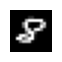

label: 2 höhe: 14 breite: 14


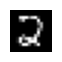

label: 1 höhe: 14 breite: 14


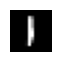

label: 2 höhe: 14 breite: 14


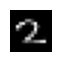

label: 2 höhe: 14 breite: 14


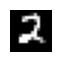

In [5]:
# einige Beispiel-Bilder darstellen, um sich einen Überblick zu verschaffen

m14x14 = pd.read_csv('class_128_14x14.csv')

dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

for i in range(1,20):
    testbild = m14x14.values[i,1:].reshape(14,14)
    testlabel = m14x14.values[i,0]
    h, w = testbild.shape
    print("label: " + str(testlabel) + " höhe: " + str(h), "breite: " + str(w))
    plt.figure(figsize=(3*w / float(dpi), 3*h / float(dpi))).add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(testbild, cmap='gray', aspect=1)
    plt.show()